c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encoun

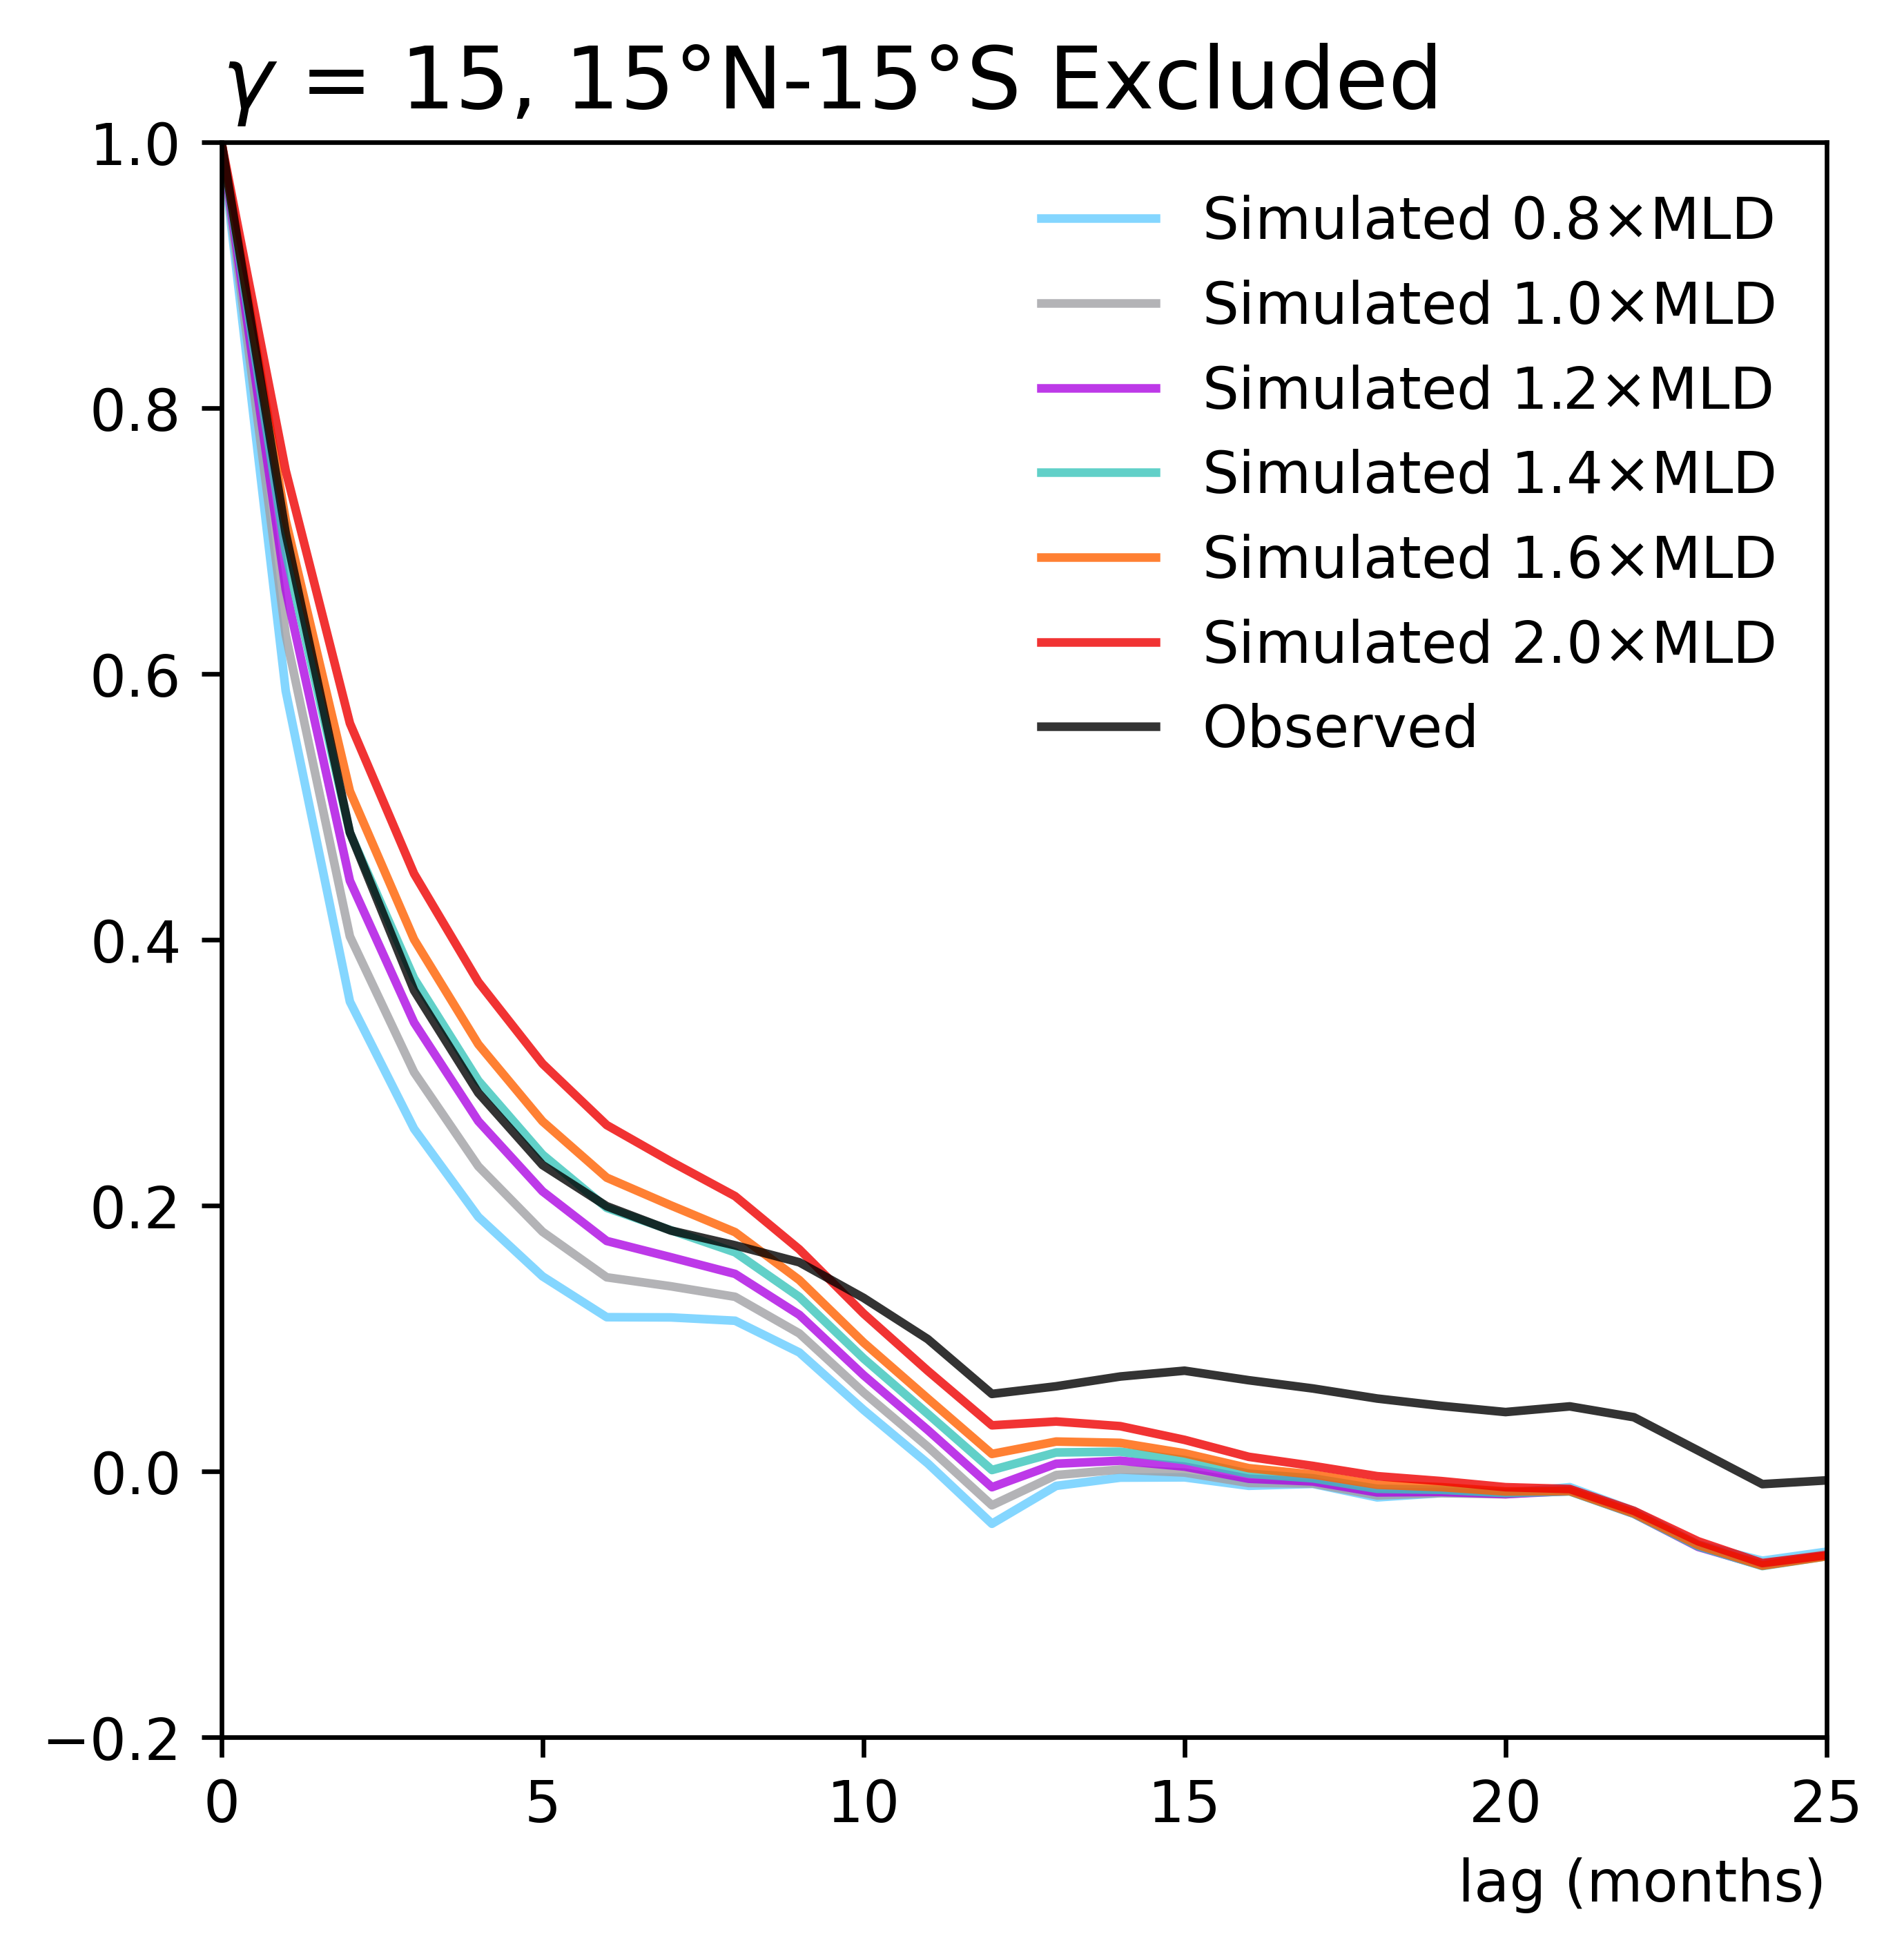

In [1]:
import xarray as xr
import numpy as np
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# import cartopy.crs as ccrs
# from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
#                                 LatitudeLocator)
# import regionmask

from utilities import load_and_prepare_dataset
from utilities import get_monthly_mean, get_anomaly
# from utilities import save_file
# from utilities_plot import make_movie_2, make_movie


SURFACE_RAD = True
SURFACE_TURB = True
ENTRAINMENT = True
EKMAN = True
GEOSTROPHIC = True
LAMBDA_A = 15
MAX_GRAD_TSUB = True

RHO_O = 1025  # kg / m^3
C_O = 4100  # J / (kg K)
SECONDS_MONTH = 30 * 24 * 60 * 60  # seconds in a month

test = [0.8, 1.0, 1.2, 1.4, 1.6, 2.0]

colours = ['#66CCFF', '#A0A0A4', '#AD07E3', "#39C5BB", '#FF6000', '#EE0000']


q_surface_ds = load_and_prepare_dataset(
    "datasets/Simulation-Surface_Heat_Flux-(2004-2025).nc"
)
q_surface_rad = (
    q_surface_ds['ANOMALY_avg_snswrf']
    + q_surface_ds['ANOMALY_avg_snlwrf']
)
q_surface_rad = q_surface_rad.drop_vars('MONTH')
q_surface_rad.name = 'ANOMALY_SURFACE_RADIATIVE_HEAT_FLUX'
q_surface_turb = (
    q_surface_ds['ANOMALY_avg_slhtf']
    + q_surface_ds['ANOMALY_avg_ishf']
)
q_surface_turb = q_surface_turb.drop_vars('MONTH')
q_surface_turb.name = 'ANOMALY_SURFACE_TURBULENT_HEAT_FLUX'
if not SURFACE_RAD:
    q_surface_rad = q_surface_rad - q_surface_rad
if not SURFACE_TURB:
    q_surface_turb = q_surface_turb - q_surface_turb

q_ekman = load_and_prepare_dataset(
    "datasets/Simulation-Ekman_Heat_Flux-(2004-2025).nc"
)['ANOMALY_EKMAN_HEAT_FLUX']
q_ekman = q_ekman.where(
    (q_ekman['LATITUDE'] > 5) | (q_ekman['LATITUDE'] < -5), 0
)
if not EKMAN:
    q_ekman = q_ekman - q_ekman

q_geostrophic = load_and_prepare_dataset(
    "datasets/Simulation-Geostrophic_Heat_Flux-(2004-2025).nc"
)['ANOMALY_GEOSTROPHIC_HEAT_FLUX']
q_geostrophic = q_geostrophic.where(
    (q_geostrophic['LATITUDE'] > 5) | (q_geostrophic['LATITUDE'] < -5), 0
)
if not GEOSTROPHIC:
    q_geostrophic = q_geostrophic - q_geostrophic

if MAX_GRAD_TSUB:
    q_entrainment = load_and_prepare_dataset(
        "datasets/Simulation-Entrainment_Heat_Flux_Max_Gradient-(2004-2025).nc"
    )['ANOMALY_ENTRAINMENT_HEAT_FLUX']
else:
    q_entrainment = load_and_prepare_dataset(
        "datasets/Simulation-Entrainment_Heat_Flux-(2004-2025).nc"
    )['ANOMALY_ENTRAINMENT_HEAT_FLUX']
w_e_monthly_mean = load_and_prepare_dataset(
    "datasets/Mixed_Layer_Entrainment_Velocity-Clim_Mean.nc"
)['MONTHLY_MEAN_w_e']
if not ENTRAINMENT:
    q_entrainment = q_entrainment - q_entrainment
    w_e_monthly_mean = w_e_monthly_mean - w_e_monthly_mean

t_m_a = load_and_prepare_dataset(
    "datasets/Mixed_Layer_Temperature_Anomalies-(2004-2025).nc"
)['ANOMALY_ML_TEMPERATURE']
t_m_a = t_m_a.drop_vars('MONTH')

t_m_a_reynolds = load_and_prepare_dataset(
    "datasets/reynolds_sst_Anomalies-(2004-2025)_no_2004.nc"
)['ANOMALY_SST']
t_m_a_reynolds = t_m_a_reynolds.drop_vars('MONTH')

if MAX_GRAD_TSUB:
    t_sub_a = load_and_prepare_dataset(
        "datasets/Sub_Layer_Temperature_Max_Gradient_Method_Anomalies-(2004-2025).nc"
    )['ANOMALY_SUB_TEMPERATURE']
else:
    t_sub_a = load_and_prepare_dataset(
        "datasets/Sub_Layer_Temperature_Anomalies-(2004-2025).nc"
    )['ANOMALY_SUB_TEMPERATURE']
t_sub_a = t_sub_a.drop_vars('MONTH')

h_monthly_mean = load_and_prepare_dataset(
    "datasets/Mixed_Layer_Depth-Clim_Mean.nc"
)['MONTHLY_MEAN_MLD']

h_monthly_mean = xr.concat([h_monthly_mean] * 22, dim='MONTH').reset_coords(drop=True)
h_monthly_mean = h_monthly_mean.rename({'MONTH': 'TIME'})
h_monthly_mean['TIME'] = t_m_a.TIME

w_e_monthly_mean = xr.concat([w_e_monthly_mean] * 22, dim='MONTH').reset_coords(drop=True)
w_e_monthly_mean = w_e_monthly_mean.rename({'MONTH': 'TIME'})
w_e_monthly_mean['TIME'] = t_m_a.TIME

result = []

for factor in test:
    dt_m_a_dt = (
        q_surface_rad
        + q_surface_turb
        + q_ekman
        + q_geostrophic
    ) / (RHO_O * C_O * h_monthly_mean * factor)

    _lambda = LAMBDA_A / (RHO_O * C_O * h_monthly_mean * factor) + w_e_monthly_mean / h_monthly_mean

    t_m_a_simulated_list = []

    for month_num in t_m_a['TIME'].values:
        if month_num == 0.5:
            t_m_a_simulated_da = t_m_a_reynolds.sel(TIME=month_num)
            temp = t_m_a_simulated_da
        else:
            t_m_a_simulated_da = (
                temp * np.exp(-_lambda.sel(TIME=month_num-1) * SECONDS_MONTH)
                + (
                    (
                        (t_sub_a.sel(TIME=month_num-1)
                         * w_e_monthly_mean.sel(TIME=month_num-1)
                         / h_monthly_mean.sel(TIME=month_num-1))
                        + dt_m_a_dt.sel(TIME=month_num-1)
                    )
                    * (1 - np.exp(-_lambda.sel(TIME=month_num-1) * SECONDS_MONTH))
                    / _lambda.sel(TIME=month_num-1)
                )
            )
            temp = t_m_a_simulated_da
        t_m_a_simulated_da = t_m_a_simulated_da.expand_dims(TIME=[month_num])
        t_m_a_simulated_list.append(t_m_a_simulated_da)

    t_m_a_simulated = xr.concat(
        t_m_a_simulated_list,
        dim="TIME",
        coords="minimal"
    )

    t_m_a_simulated.name = 'TA_SIMULATED'
    t_m_a_simulated.attrs['units'] = 'K'

    t_m_a_simulated_monthly_mean = get_monthly_mean(
        t_m_a_simulated.where(t_m_a.TIME >= 12.5, drop=True)
    )
    t_m_a_simulated = get_anomaly(t_m_a_simulated, t_m_a_simulated_monthly_mean)
    t_m_a_simulated = t_m_a_simulated.drop_vars('MONTH')

    result.append(t_m_a_simulated)


# autocorrelation plot
# ----------------------------------------------------------------------------

t_m_a_reynolds = t_m_a_reynolds.where(
    (t_m_a_reynolds['LATITUDE'] > 15) | (t_m_a_reynolds['LATITUDE'] < -15), 0
)

plt.figure(figsize=(5, 5), dpi=600)

for count, t_m_a_simulated in enumerate(result):
    t_m_a_simulated = t_m_a_simulated.where(
        (t_m_a_simulated['LATITUDE'] > 15) | (t_m_a_simulated['LATITUDE'] < -15), 0
    )

    autocorr_points_simulated = []
    autocorr_points_observed = []
    for lon, lat in zip(t_m_a_simulated['LONGITUDE'], t_m_a_simulated['LATITUDE']):
        autocorr_point_simulated = acf(t_m_a_simulated.sel(LONGITUDE=lon, LATITUDE=lat), nlags=25)
        autocorr_point_observed = acf(t_m_a_reynolds.sel(LONGITUDE=lon, LATITUDE=lat), nlags=25)
        if not np.isnan(autocorr_point_simulated).all():
            autocorr_points_simulated.append(autocorr_point_simulated)
        if not np.isnan(autocorr_point_observed).all():
            autocorr_points_observed.append(autocorr_point_observed)
    autocorr_points_simulated = np.array(autocorr_points_simulated)
    autocorr_points_observed = np.array(autocorr_points_observed)

    plt.plot(
        autocorr_points_simulated.mean(axis=0),
        label=f'Simulated {test[count]}'+r'$\times$MLD',
        color=colours[count], alpha=0.8
    )

plt.plot(
    autocorr_points_observed.mean(axis=0),
    label='Observed',
    color='black', alpha=0.8
)

plt.xlim(0, 25)
plt.xlabel('lag (months)', loc='right')
plt.ylim(-0.2, 1)

plt.legend(frameon=False)
plt.title(r'$\gamma$'+f' = {LAMBDA_A}, 15°N-15°S Excluded', fontsize=15, loc='left')

plt.show()


c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encountered in divide
  acf = avf[: nlags + 1] / avf[0]
c:\Users\zhuch\Desktop\SSTA\.ss_venv\Lib\site-packages\statsmodels\tsa\stattools.py:702: RuntimeWarning: invalid value encoun

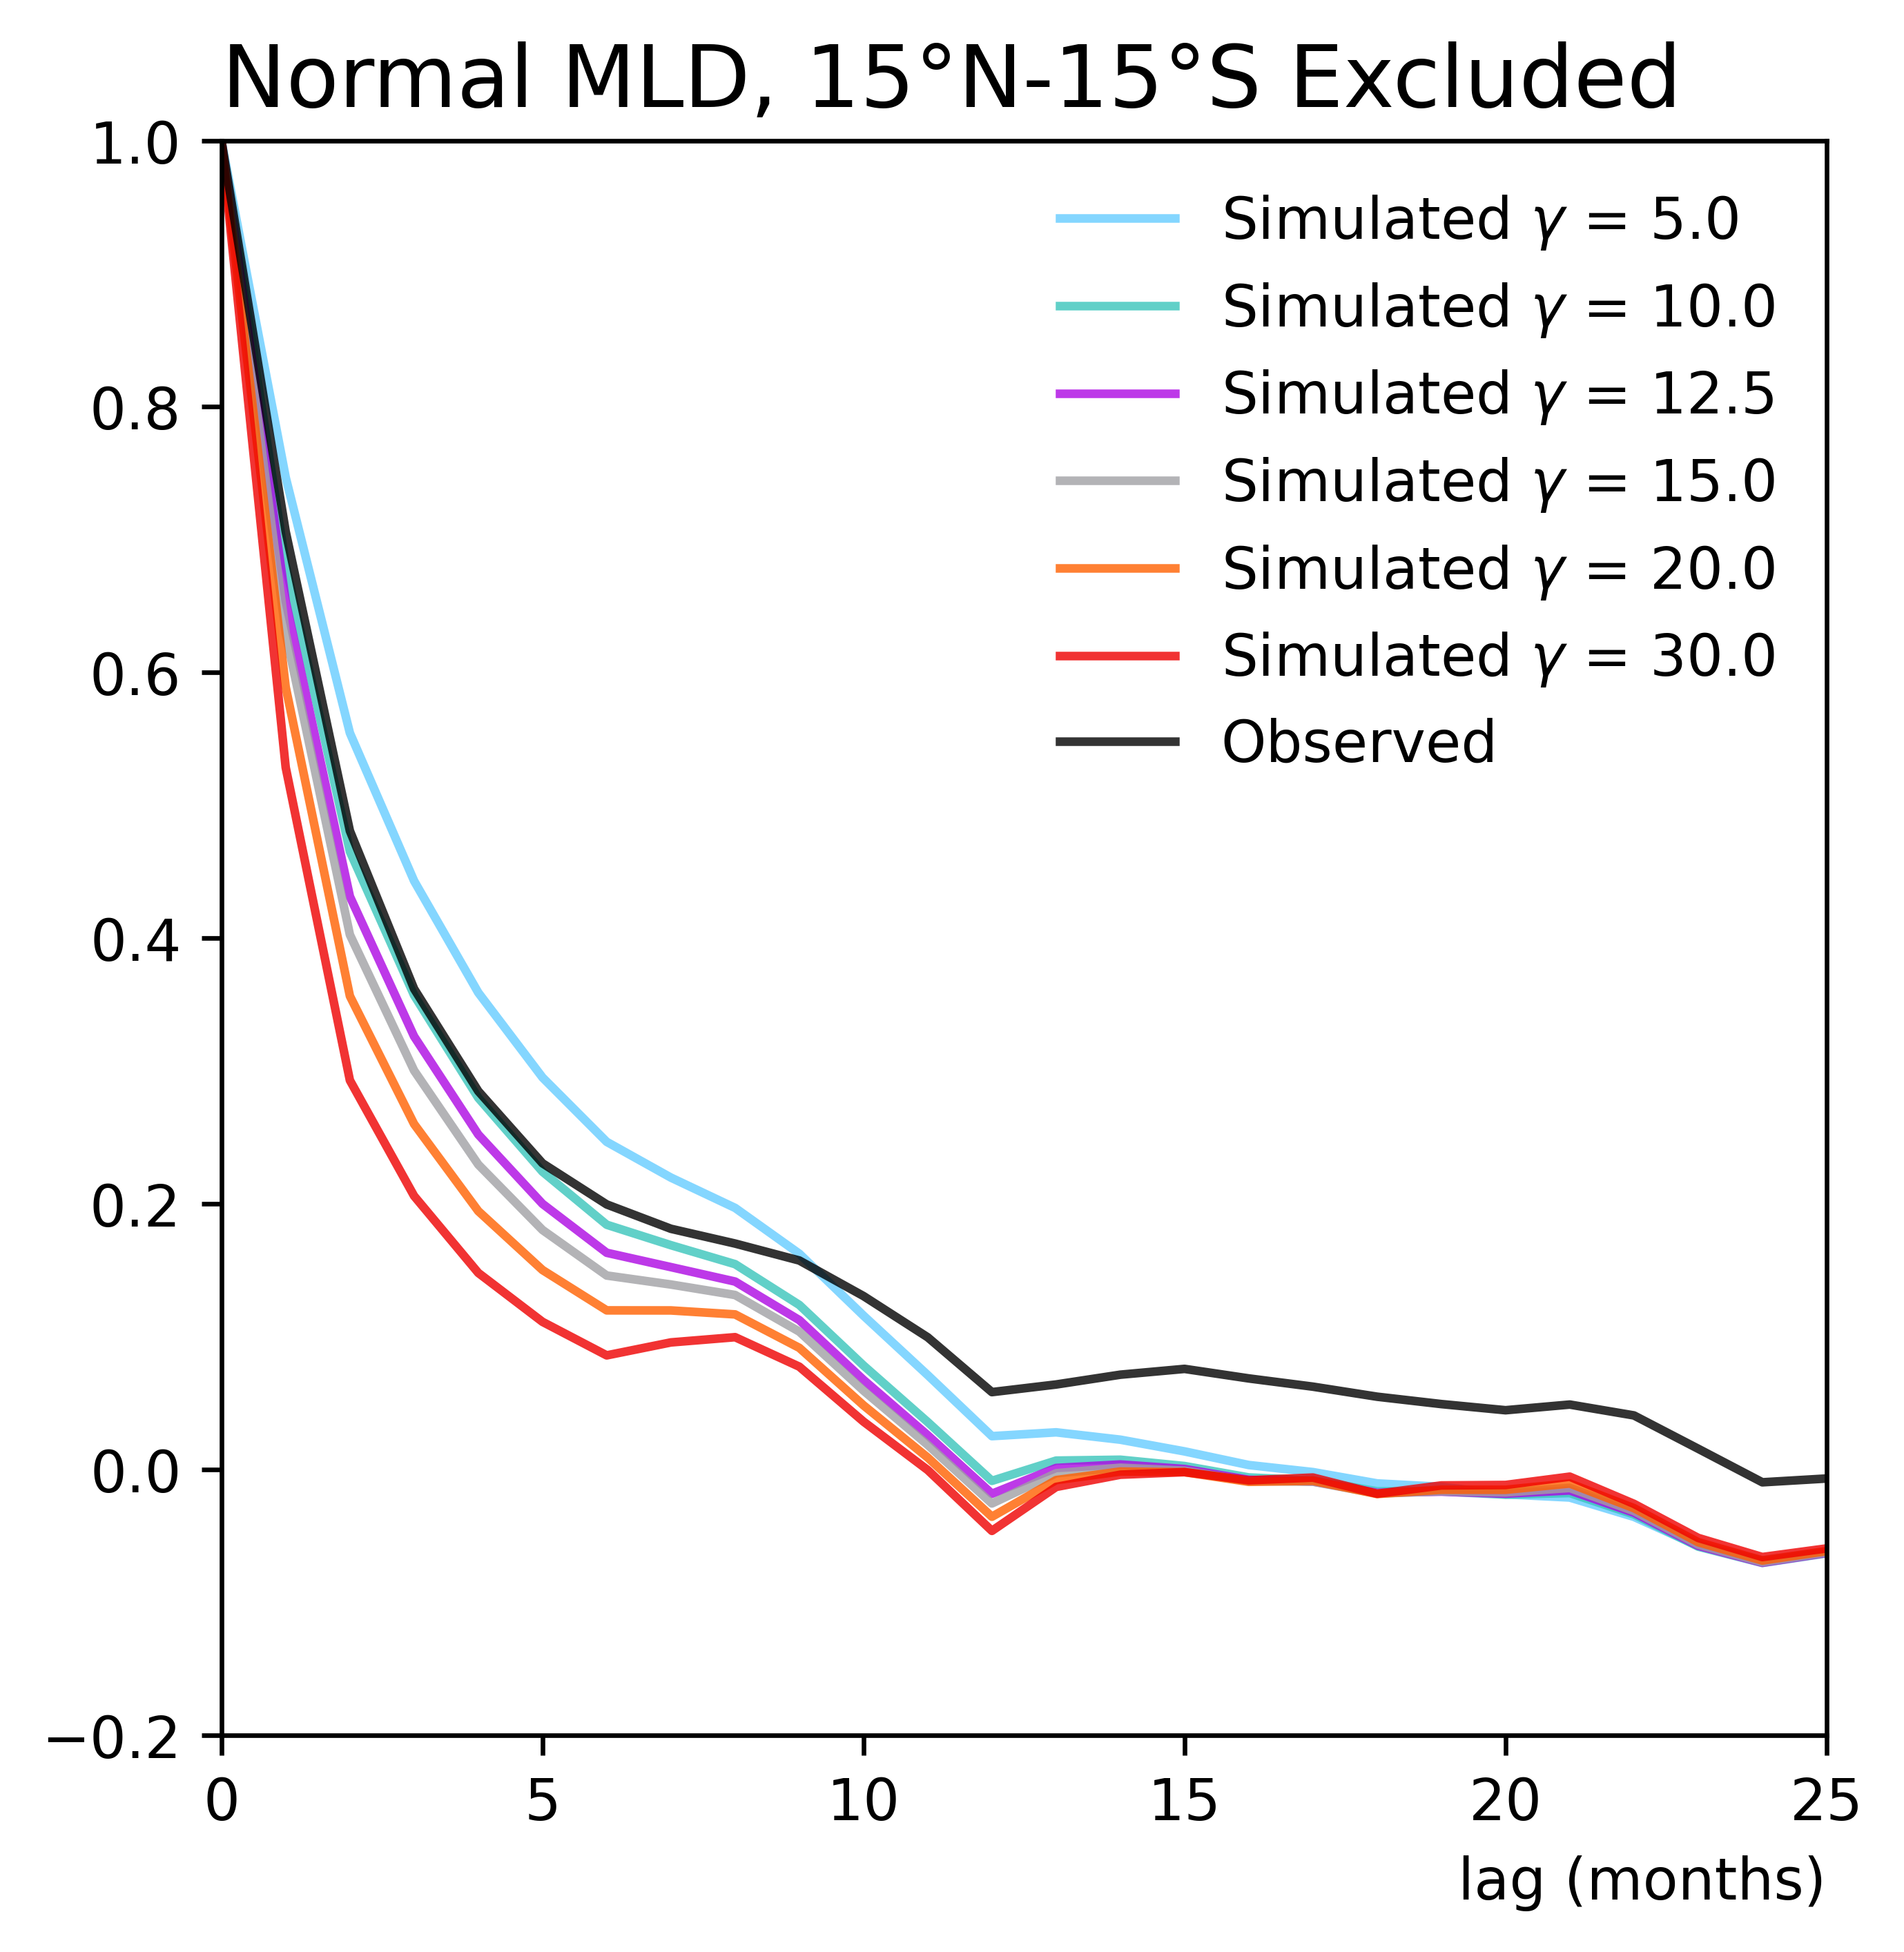

In [2]:
import xarray as xr
import numpy as np
from statsmodels.tsa.stattools import acf
import matplotlib.pyplot as plt
# import matplotlib.ticker as mticker
# import cartopy.crs as ccrs
# from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
#                                 LatitudeLocator)
# import regionmask

from utilities import load_and_prepare_dataset
from utilities import get_monthly_mean, get_anomaly
# from utilities import save_file
# from utilities_plot import make_movie_2, make_movie


SURFACE_RAD = True
SURFACE_TURB = True
ENTRAINMENT = True
EKMAN = True
GEOSTROPHIC = True
# LAMBDA_A = 15
MAX_GRAD_TSUB = True

RHO_O = 1025  # kg / m^3
C_O = 4100  # J / (kg K)
SECONDS_MONTH = 30 * 24 * 60 * 60  # seconds in a month

test = [5.0, 10.0, 12.5, 15.0, 20.0, 30.0]

colours = ['#66CCFF', "#39C5BB", '#AD07E3', '#A0A0A4', '#FF6000', '#EE0000']


q_surface_ds = load_and_prepare_dataset(
    "datasets/Simulation-Surface_Heat_Flux-(2004-2025).nc"
)
q_surface_rad = (
    q_surface_ds['ANOMALY_avg_snswrf']
    + q_surface_ds['ANOMALY_avg_snlwrf']
)
q_surface_rad = q_surface_rad.drop_vars('MONTH')
q_surface_rad.name = 'ANOMALY_SURFACE_RADIATIVE_HEAT_FLUX'
q_surface_turb = (
    q_surface_ds['ANOMALY_avg_slhtf']
    + q_surface_ds['ANOMALY_avg_ishf']
)
q_surface_turb = q_surface_turb.drop_vars('MONTH')
q_surface_turb.name = 'ANOMALY_SURFACE_TURBULENT_HEAT_FLUX'
if not SURFACE_RAD:
    q_surface_rad = q_surface_rad - q_surface_rad
if not SURFACE_TURB:
    q_surface_turb = q_surface_turb - q_surface_turb

q_ekman = load_and_prepare_dataset(
    "datasets/Simulation-Ekman_Heat_Flux-(2004-2025).nc"
)['ANOMALY_EKMAN_HEAT_FLUX']
q_ekman = q_ekman.where(
    (q_ekman['LATITUDE'] > 5) | (q_ekman['LATITUDE'] < -5), 0
)
if not EKMAN:
    q_ekman = q_ekman - q_ekman

q_geostrophic = load_and_prepare_dataset(
    "datasets/Simulation-Geostrophic_Heat_Flux-(2004-2025).nc"
)['ANOMALY_GEOSTROPHIC_HEAT_FLUX']
q_geostrophic = q_geostrophic.where(
    (q_geostrophic['LATITUDE'] > 5) | (q_geostrophic['LATITUDE'] < -5), 0
)
if not GEOSTROPHIC:
    q_geostrophic = q_geostrophic - q_geostrophic

if MAX_GRAD_TSUB:
    q_entrainment = load_and_prepare_dataset(
        "datasets/Simulation-Entrainment_Heat_Flux_Max_Gradient-(2004-2025).nc"
    )['ANOMALY_ENTRAINMENT_HEAT_FLUX']
else:
    q_entrainment = load_and_prepare_dataset(
        "datasets/Simulation-Entrainment_Heat_Flux-(2004-2025).nc"
    )['ANOMALY_ENTRAINMENT_HEAT_FLUX']
w_e_monthly_mean = load_and_prepare_dataset(
    "datasets/Mixed_Layer_Entrainment_Velocity-Clim_Mean.nc"
)['MONTHLY_MEAN_w_e']
if not ENTRAINMENT:
    q_entrainment = q_entrainment - q_entrainment
    w_e_monthly_mean = w_e_monthly_mean - w_e_monthly_mean

t_m_a = load_and_prepare_dataset(
    "datasets/Mixed_Layer_Temperature_Anomalies-(2004-2025).nc"
)['ANOMALY_ML_TEMPERATURE']
t_m_a = t_m_a.drop_vars('MONTH')

t_m_a_reynolds = load_and_prepare_dataset(
    "datasets/reynolds_sst_Anomalies-(2004-2025)_no_2004.nc"
)['ANOMALY_SST']
t_m_a_reynolds = t_m_a_reynolds.drop_vars('MONTH')

if MAX_GRAD_TSUB:
    t_sub_a = load_and_prepare_dataset(
        "datasets/Sub_Layer_Temperature_Max_Gradient_Method_Anomalies-(2004-2025).nc"
    )['ANOMALY_SUB_TEMPERATURE']
else:
    t_sub_a = load_and_prepare_dataset(
        "datasets/Sub_Layer_Temperature_Anomalies-(2004-2025).nc"
    )['ANOMALY_SUB_TEMPERATURE']
t_sub_a = t_sub_a.drop_vars('MONTH')

h_monthly_mean = load_and_prepare_dataset(
    "datasets/Mixed_Layer_Depth-Clim_Mean.nc"
)['MONTHLY_MEAN_MLD']

h_monthly_mean = xr.concat([h_monthly_mean] * 22, dim='MONTH').reset_coords(drop=True)
h_monthly_mean = h_monthly_mean.rename({'MONTH': 'TIME'})
h_monthly_mean['TIME'] = t_m_a.TIME

w_e_monthly_mean = xr.concat([w_e_monthly_mean] * 22, dim='MONTH').reset_coords(drop=True)
w_e_monthly_mean = w_e_monthly_mean.rename({'MONTH': 'TIME'})
w_e_monthly_mean['TIME'] = t_m_a.TIME

result = []

for LAMBDA_A in test:
    dt_m_a_dt = (
        q_surface_rad
        + q_surface_turb
        + q_ekman
        + q_geostrophic
    ) / (RHO_O * C_O * h_monthly_mean)

    _lambda = LAMBDA_A / (RHO_O * C_O * h_monthly_mean) + w_e_monthly_mean / h_monthly_mean

    t_m_a_simulated_list = []

    for month_num in t_m_a['TIME'].values:
        if month_num == 0.5:
            t_m_a_simulated_da = t_m_a_reynolds.sel(TIME=month_num)
            temp = t_m_a_simulated_da
        else:
            t_m_a_simulated_da = (
                temp * np.exp(-_lambda.sel(TIME=month_num-1) * SECONDS_MONTH)
                + (
                    (
                        (t_sub_a.sel(TIME=month_num-1)
                         * w_e_monthly_mean.sel(TIME=month_num-1)
                         / h_monthly_mean.sel(TIME=month_num-1))
                        + dt_m_a_dt.sel(TIME=month_num-1)
                    )
                    * (1 - np.exp(-_lambda.sel(TIME=month_num-1) * SECONDS_MONTH))
                    / _lambda.sel(TIME=month_num-1)
                )
            )
            temp = t_m_a_simulated_da
        t_m_a_simulated_da = t_m_a_simulated_da.expand_dims(TIME=[month_num])
        t_m_a_simulated_list.append(t_m_a_simulated_da)

    t_m_a_simulated = xr.concat(
        t_m_a_simulated_list,
        dim="TIME",
        coords="minimal"
    )

    t_m_a_simulated.name = 'TA_SIMULATED'
    t_m_a_simulated.attrs['units'] = 'K'

    t_m_a_simulated_monthly_mean = get_monthly_mean(
        t_m_a_simulated.where(t_m_a.TIME >= 12.5, drop=True)
    )
    t_m_a_simulated = get_anomaly(t_m_a_simulated, t_m_a_simulated_monthly_mean)
    t_m_a_simulated = t_m_a_simulated.drop_vars('MONTH')

    result.append(t_m_a_simulated)


# autocorrelation plot
# ----------------------------------------------------------------------------

t_m_a_reynolds = t_m_a_reynolds.where(
    (t_m_a_reynolds['LATITUDE'] > 15) | (t_m_a_reynolds['LATITUDE'] < -15), 0
)

plt.figure(figsize=(5, 5), dpi=600)

for count, t_m_a_simulated in enumerate(result):
    t_m_a_simulated = t_m_a_simulated.where(
        (t_m_a_simulated['LATITUDE'] > 15) | (t_m_a_simulated['LATITUDE'] < -15), 0
    )

    autocorr_points_simulated = []
    autocorr_points_observed = []
    for lon, lat in zip(t_m_a_simulated['LONGITUDE'], t_m_a_simulated['LATITUDE']):
        autocorr_point_simulated = acf(t_m_a_simulated.sel(LONGITUDE=lon, LATITUDE=lat), nlags=25)
        autocorr_point_observed = acf(t_m_a_reynolds.sel(LONGITUDE=lon, LATITUDE=lat), nlags=25)
        if not np.isnan(autocorr_point_simulated).all():
            autocorr_points_simulated.append(autocorr_point_simulated)
        if not np.isnan(autocorr_point_observed).all():
            autocorr_points_observed.append(autocorr_point_observed)
    autocorr_points_simulated = np.array(autocorr_points_simulated)
    autocorr_points_observed = np.array(autocorr_points_observed)

    plt.plot(
        autocorr_points_simulated.mean(axis=0),
        label=r'Simulated $\gamma$'+f' = {test[count]}',
        color=colours[count], alpha=0.8
    )

plt.plot(
    autocorr_points_observed.mean(axis=0),
    label='Observed',
    color='black', alpha=0.8
)

plt.xlim(0, 25)
plt.xlabel('lag (months)', loc='right')
plt.ylim(-0.2, 1)

plt.legend(frameon=False)
plt.title('Normal MLD, 15°N-15°S Excluded', fontsize=15, loc='left')

plt.show()
